#Part 1: Preprocessing

**Step 0: Import Libraries**

In this step, we import all the libraries we will need for the data pipeline and training utilities.

In [ ]:
# Step 0: Import Libraries

import random

import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import os
from torchvision.datasets import ImageFolder
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split

**Step 2: Load and Explore the datasets.SVHN Dataset and Transform**

In this step, we load the diabetes dataset from TorchVision and take a quick look at the shapes of the features and targets. The transformation converts the images into a PyTorch tensor, normalizes each pixel using a mean and standard deviation of (0.5, 0.5, 0.5), and randomly converts the image to grayscale to make the model is less dependent on color.

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)), # normalize each channel (R,G,B)
    transforms.RandomGrayscale() # add a random grayscale to the images
])

#Load Datasets
train_and_validation_dataset = datasets.SVHN(
    root='./data',
    split='train',
    transform=transform,
    download=True
)

test_dataset = datasets.SVHN(
    root='./data',
    split='test',
    transform=transform,
    download=True
)

100%|██████████| 182M/182M [00:10<00:00, 18.1MB/s]
100%|██████████| 64.3M/64.3M [00:06<00:00, 10.3MB/s]


**Step 3: Train/Validation/Test Split**

We now split the dataset into train, validation, and test sets.
We also apply StandardScaler so that all features are on a comparable scale.

In [ ]:
# Split train into train + validation
train_size = int(0.8 * len(train_and_validation_dataset))   # 80% train
validation_size = len(train_and_validation_dataset) - train_size   # 20% validation

train_dataset, validation_dataset = random_split(
    train_and_validation_dataset,
    [train_size, validation_size]
)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Training samples: 58605
Validation samples: 14652
Test samples: 26032


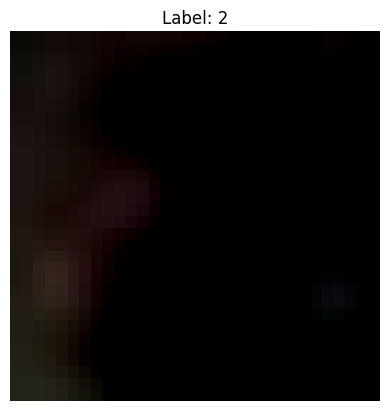

In [ ]:
classes = [str(i) for i in range(10)]
print("Classes:", classes)

# Dataset sizes
print("Training samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))
print("Test samples:", len(test_dataset))

image, label = train_dataset[0]

label = 0 if label == 10 else label

img = image.permute(1, 2, 0) # convert image from PyTorch format (C, H, W) to display format (H, W, C)

# preview our dataset as well as the classes
plt.imshow(img)
plt.title(f"Label: {classes[label]}")
plt.axis('off')
plt.show()

**Step 4: Create PyTorch Datasets and DataLoaders**

The other models in our project will be implemented in PyTorch.
Here we wrap the NumPy arrays into TensorDatasets and DataLoaders so that batching and shuffling are handled automatically.

In [ ]:
# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

**Step 5: Define Shared Training and Evaluation Utilities**

All deep learning models (MLP, RNN, CNN) will use the same training and evaluation functions.
This keeps the comparison fair and reduces duplicated code.

In [ ]:
def train(model, device, train_loader, optimizer, epoch, criterion):
    # set model to training mode
    model.train()
    epoch_loss = 0.0
    total_samples = 0
    correct_predictions = 0

    # loop through each batch
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()  # reset gradients
        outputs = model(inputs)
        loss = criterion(outputs, labels) # compute the loss
        loss.backward() # backpropagation
        optimizer.step()

        # accumulate total loss for the epoch
        epoch_loss += loss.item() * inputs.size(0)
        total_samples += labels.size(0)

        preds = outputs.argmax(dim=1, keepdim=True) # compute predictions
        correct_predictions += preds.eq(labels.view_as(preds)).sum().item() # count correct predictions

    # average epoch loss and accuracy
    avg_train_loss = epoch_loss / total_samples
    train_accuracy = 100.0 * correct_predictions / total_samples

    print(
        f"Epoch [{epoch}]:\n"
        f"Training set: Average loss: {avg_train_loss:.4f}, "
        f"Accuracy: {correct_predictions}/{len(train_loader.dataset)} ({train_accuracy:.2f}%)"
    )

    return avg_train_loss


# Validation loop
def validate(model, device, validate_loader, criterion):
    # set model to evaluation mode
    model.eval()
    cumulative_val_loss = 0.0
    correct_predictions = 0

    # evaluation = no gradient tracking
    with torch.no_grad():
        for inputs, labels in validate_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # forward pass
            outputs = model(inputs)
            cumulative_val_loss += criterion(outputs, labels).item()  # accumulate validation loss (mean later)

            preds = outputs.argmax(dim=1, keepdim=True)
            correct_predictions += preds.eq(labels.view_as(preds)).sum().item()

    # compute mean validation loss
    avg_val_loss = cumulative_val_loss / len(validate_loader)
    val_accuracy = 100.0 * correct_predictions / len(validate_loader.dataset)
    print(f"Validation set: Average loss: {avg_val_loss:.4f}, Accuracy: {correct_predictions}/{len(validate_loader.dataset)} ({val_accuracy:.2f}%)\n")

    return avg_val_loss


# Testing loop
def test(model, criterion):
    # set model to evaluation mode
    model.eval()
    total_test_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            loss = criterion(outputs, labels) # calculate batch loss
            total_test_loss += loss.item() * inputs.size(0) # accumulate total test loss

            # get predicted class
            _, preds = torch.max(outputs, 1)
            total_samples += labels.size(0)
            correct_predictions += (preds == labels).sum().item()

    # average loss and accuracy
    avg_test_loss = total_test_loss / total_samples
    test_accuracy = 100.0 * correct_predictions / total_samples

    print(f"Test Loss: {avg_test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")


**Step 6: Define Plotting Functions**

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Loss plot
def plot_fn(train_loss_list, val_loss_list):
    plt.figure(figsize=(12,5))

    # plot training loss trend and validation loss trend
    plt.plot(train_loss_list, label='Train Loss')
    plt.plot(val_loss_list, label='Val Loss')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


# Confusion Matrix
def confusion(model, validation_loader):
    model.eval()

    # store predictions and ground truth
    predicted_labels, true_labels = [], []

    with torch.no_grad():
        for batch_inputs, batch_targets in validation_loader:
            batch_inputs = batch_inputs.to(device)
            batch_targets = batch_targets.to(device)

            # forward pass
            outputs = model(batch_inputs)

            # get predicted class index
            _, batch_preds = torch.max(outputs, 1)

            # collect results
            predicted_labels.extend(batch_preds.cpu().numpy())
            true_labels.extend(batch_targets.cpu().numpy())

    # compute confusion matrix from lists
    c_matrix = confusion_matrix(true_labels, predicted_labels)

    # plot confusion matrix with class names
    disp = ConfusionMatrixDisplay(confusion_matrix=c_matrix, display_labels=classes)
    disp.plot(xticks_rotation='vertical')

    plt.show()



## Part 2: Define MLP Model

The MLP model takes a flattened 32×32×3 image as input and passes it through two fully connected hidden layers with 256 neurons each, using ReLU activations to introduce non-linearity. The final output layer produces 10 class scores corresponding to the digit classes (0–9).




In [ ]:
import torch
import torch.nn as nn
from torchsummary import summary

class MLPClassifier(nn.Module):
    def __init__(self, input_size=3*32*32, hidden_units=256, num_classes=10): # 3x32x32 for each pixel of the image
        super(MLPClassifier, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden_units), # dense layer 1
            nn.ReLU(),
            nn.Linear(hidden_units, hidden_units), # dense layer 2
            nn.ReLU(),
            nn.Linear(hidden_units, num_classes) # output layer (10 classes for each digit)
        )

    def forward(self, x):
        return self.model(x)


# Create model
MLP_model = MLPClassifier().to(device)

# Print model
print(MLP_model)

summary(MLP_model, (3, 32, 32))



MLPClassifier(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                 [-1, 3072]               0
            Linear-2                  [-1, 256]         786,688
              ReLU-3                  [-1, 256]               0
            Linear-4                  [-1, 256]          65,792
              ReLU-5                  [-1, 256]               0
            Linear-6                   [-1, 10]           2,570
Total params: 855,050
Trainable params: 855,050
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass si

## Part 3: Define RNN Model

This is a simple RNN regressor where each feature of the diabetes dataset is treated as a sequential timestep. The RNN layer processes these “timesteps” to capture relationships between features, and the final output is passed through a linear layer to predict a single value. Input data is reshaped to (batch_size, input_dim, 1) to match the RNN’s expected input format.

In [ ]:
import torch
import torch.nn as nn
from torchsummary import summary

class RNNClassifier(nn.Module):
    def __init__(self, input_size=96, hidden_units=128, num_layers=1, num_classes=10):
        super().__init__()
        self.hidden_units = hidden_units
        self.num_layers = num_layers

        # RNN layer
        self.rnn = nn.RNN(
            input_size=input_size,     # number of features per timestep
            hidden_size=hidden_units,  # hidden state size
            num_layers=num_layers,     # stacked RNN layers
            batch_first=True,          # input format: (batch, seq, feature)
            nonlinearity="tanh"        # activation function
        )

        # fullt connected layer
        self.fc = nn.Linear(hidden_units, num_classes)

    def forward(self, x):

        # reorder dimensions: (batch, channel, height, width) → (batch, height, width, channel)
        x = x.permute(0, 2, 3, 1)

        # flatten width*channels as sequence features → (batch, seq_len=32, features=32*3)
        x = x.reshape(x.size(0), 32, 32 * 3)

        rnn_out, _ = self.rnn(x)

        # get output from the last timestep of the sequence
        last_output = rnn_out[:, -1, :]
        out = self.fc(last_output)

        return out


RNN_model = RNNClassifier().to(device)
print(RNN_model)

# Summary
summary(RNN_model, input_size=(3, 32, 32))



RNNClassifier(
  (rnn): RNN(96, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
               RNN-1  [[-1, 32, 128], [-1, 2, 128]]               0
            Linear-2                   [-1, 10]           1,290
Total params: 1,290
Trainable params: 1,290
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 8.00
Params size (MB): 0.00
Estimated Total Size (MB): 8.02
----------------------------------------------------------------


## Part 4: Define CNN Model
This model is a 2D Convolutional Neural Network (CNN) designed for regression or classification on data with 3 input channels. It extracts spatial patterns using two 2D convolution layers (conv1 and conv2) to learn hierarchical features from the input, followed by a max-pooling layer to reduce dimensionality and focus on the most relevant features. Then finally goes through a dropout layer for better generalization, and outputs a 10-dimensional prediction vector.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Convolutional layers for RGB images (3 channels)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)   # output: 32×32×32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # output: 64×32×32

        self.pool = nn.MaxPool2d(2, 2)  # 32→16 → 8 after 2 pools
        self.dropout = nn.Dropout(0.25)

        # After two conv+pool:
        # 32x32 → 16x16 → 8x8
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 classes for SVHN

    def forward(self, x):
        x = F.relu(self.conv1(x))       # 32×32×32
        x = self.pool(x)                # 32×16×16

        x = F.relu(self.conv2(x))       # 64×16×16
        x = self.pool(x)                # 64×8×8

        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


CNN_model = CNN().to(device)
print(CNN_model)

# Summary for SVHN images: 3 channels, 32x32
summary(CNN_model, (3, 32, 32))


CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
         MaxPool2d-2           [-1, 32, 16, 16]               0
            Conv2d-3           [-1, 64, 16, 16]          18,496
         MaxPool2d-4             [-1, 64, 8, 8]               0
           Dropout-5                 [-1, 4096]               0
            Linear-6                  [-1, 128]         524,416
            Linear-7                   [-1, 10]           1,290
Total para

## Part 5: Run Training, Validation and Testing
Once the model architectures were defined, we proceeded with a 5-epoch training process. After training, we plotted both training and validation losses and later visualized them alongside a confusion matrix to evaluate model performance.

### Define Optimizer and Loss

In [ ]:
# Define loss function
criterion = nn.CrossEntropyLoss()

# Define optimizers for each model, Adam with a learning rate of 0.001
MLP_optimizer = torch.optim.Adam(MLP_model.parameters(), lr=0.001)
RNN_optimizer = torch.optim.Adam(RNN_model.parameters(), lr=0.001)
CNN_optimizer = torch.optim.Adam(CNN_model.parameters(), lr=0.001)


### MLP Model: Training, Validation and Testing

In [ ]:
# Run Training and validation loops for MLP
num_epochs = 5
mlp_train_losses, mlp_validation_losses = [], []

for epoch in range(1, num_epochs + 1):
    print(f"\nEpoch [{epoch}/{num_epochs}]")
    train_loss = train(MLP_model, device, train_loader, MLP_optimizer, epoch, criterion)
    validation_loss = validate(MLP_model, device, validation_loader, criterion)

    mlp_train_losses.append(train_loss)
    mlp_validation_losses.append(validation_loss)


Epoch [1/5]
Epoch [1]:
Training set: Average loss: 1.1970, Accuracy: 35988/58605 (61.41%)
Validation set: Average loss: 0.9708, Accuracy: 10160/14652 (69.34%)


Epoch [2/5]
Epoch [2]:
Training set: Average loss: 0.8201, Accuracy: 43797/58605 (74.73%)
Validation set: Average loss: 0.8559, Accuracy: 10828/14652 (73.90%)


Epoch [3/5]
Epoch [3]:
Training set: Average loss: 0.7062, Accuracy: 45885/58605 (78.30%)
Validation set: Average loss: 0.7353, Accuracy: 11447/14652 (78.13%)


Epoch [4/5]
Epoch [4]:
Training set: Average loss: 0.6317, Accuracy: 47327/58605 (80.76%)
Validation set: Average loss: 0.7455, Accuracy: 11414/14652 (77.90%)


Epoch [5/5]
Epoch [5]:
Training set: Average loss: 0.5821, Accuracy: 48162/58605 (82.18%)
Validation set: Average loss: 0.6930, Accuracy: 11680/14652 (79.72%)



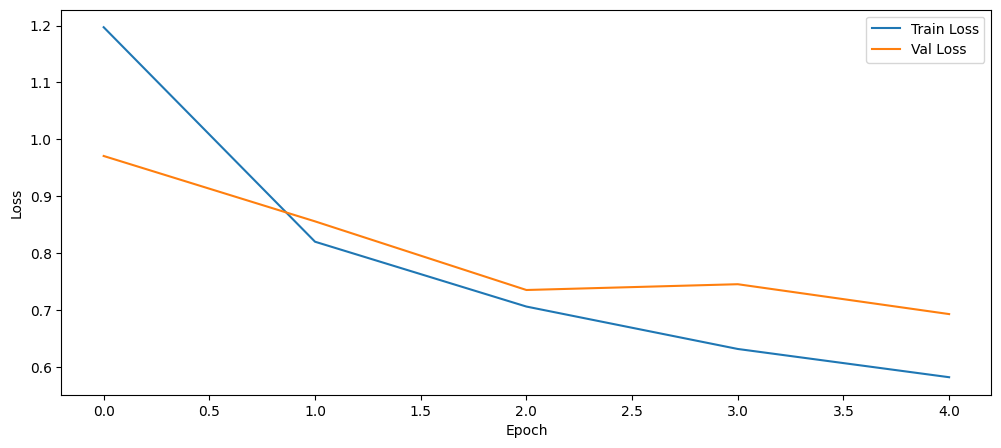

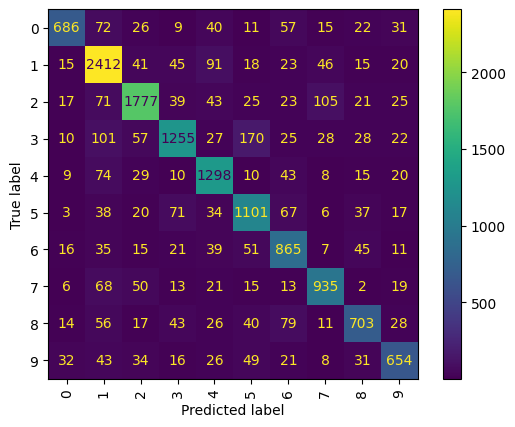

In [ ]:
plot_fn(mlp_train_losses, mlp_validation_losses)
confusion(MLP_model,validation_loader)

### RNN Model: Training, Validation and Testing

In [ ]:
# Run Training and validation loops for RNN
num_epochs = 5
rnn_train_losses, rnn_validation_losses = [], []

for epoch in range(1, num_epochs + 1):
    print(f"\nEpoch [{epoch}/{num_epochs}]")
    train_loss = train(RNN_model, device, train_loader, RNN_optimizer, epoch, criterion)
    validation_loss = validate(RNN_model, device, validation_loader, criterion)

    rnn_train_losses.append(train_loss)
    rnn_validation_losses.append(validation_loss)


Epoch [1/5]
Epoch [1]:
Training set: Average loss: 2.0385, Accuracy: 15595/58605 (26.61%)
Validation set: Average loss: 1.7478, Accuracy: 5699/14652 (38.90%)


Epoch [2/5]
Epoch [2]:
Training set: Average loss: 1.5592, Accuracy: 26585/58605 (45.36%)
Validation set: Average loss: 1.4262, Accuracy: 7411/14652 (50.58%)


Epoch [3/5]
Epoch [3]:
Training set: Average loss: 1.3469, Accuracy: 31609/58605 (53.94%)
Validation set: Average loss: 1.3623, Accuracy: 7956/14652 (54.30%)


Epoch [4/5]
Epoch [4]:
Training set: Average loss: 1.2443, Accuracy: 34051/58605 (58.10%)
Validation set: Average loss: 1.2797, Accuracy: 8483/14652 (57.90%)


Epoch [5/5]
Epoch [5]:
Training set: Average loss: 1.1924, Accuracy: 35295/58605 (60.23%)
Validation set: Average loss: 1.1756, Accuracy: 9064/14652 (61.86%)



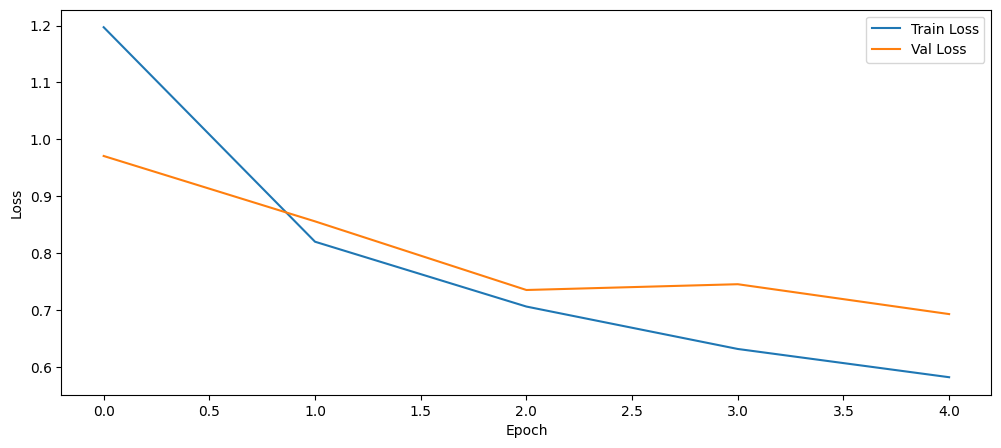

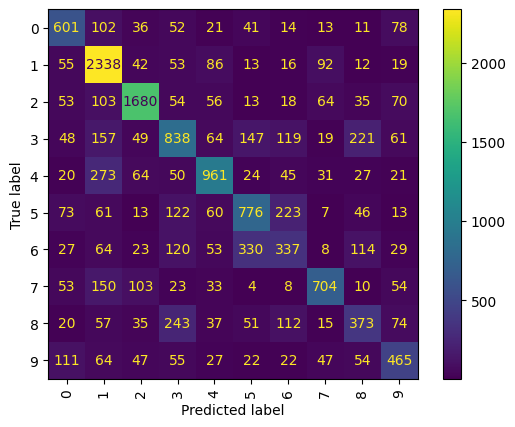

In [ ]:
plot_fn(mlp_train_losses, mlp_validation_losses)
confusion(RNN_model,validation_loader)

### CNN Model: Training, Validation and Testing

In [ ]:
# Run Training and validation loops for CNN
num_epochs = 5
cnn_train_losses, cnn_validation_losses = [], []

for epoch in range(1, num_epochs + 1):
    print(f"\nEpoch [{epoch}/{num_epochs}]")
    train_loss = train(CNN_model, device, train_loader, CNN_optimizer, epoch, criterion)
    validation_loss = validate(CNN_model, device, validation_loader, criterion)

    cnn_train_losses.append(train_loss)
    cnn_validation_losses.append(validation_loss)


Epoch [1/5]
Epoch [1]:
Training set: Average loss: 0.9476, Accuracy: 40924/58605 (69.83%)
Validation set: Average loss: 0.5612, Accuracy: 12363/14652 (84.38%)


Epoch [2/5]
Epoch [2]:
Training set: Average loss: 0.5146, Accuracy: 49769/58605 (84.92%)
Validation set: Average loss: 0.4635, Accuracy: 12751/14652 (87.03%)


Epoch [3/5]
Epoch [3]:
Training set: Average loss: 0.4241, Accuracy: 51173/58605 (87.32%)
Validation set: Average loss: 0.4214, Accuracy: 12884/14652 (87.93%)


Epoch [4/5]
Epoch [4]:
Training set: Average loss: 0.3726, Accuracy: 52096/58605 (88.89%)
Validation set: Average loss: 0.3936, Accuracy: 12987/14652 (88.64%)


Epoch [5/5]
Epoch [5]:
Training set: Average loss: 0.3325, Accuracy: 52670/58605 (89.87%)
Validation set: Average loss: 0.3911, Accuracy: 12998/14652 (88.71%)



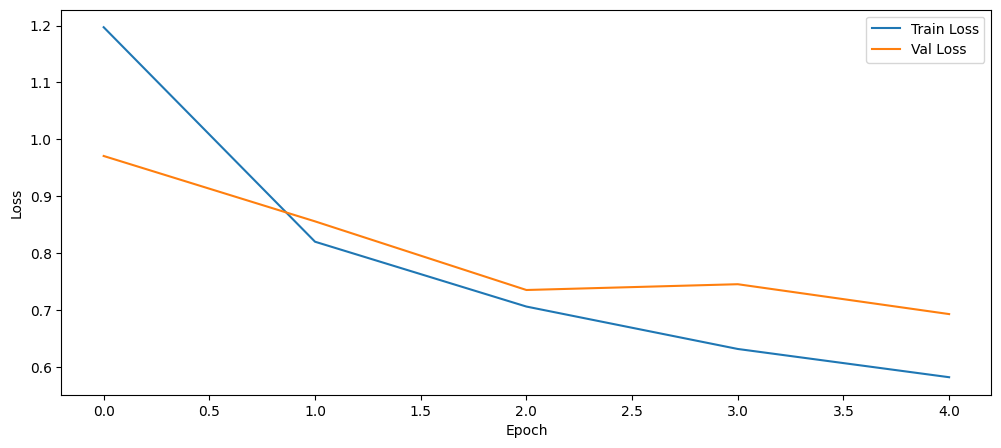

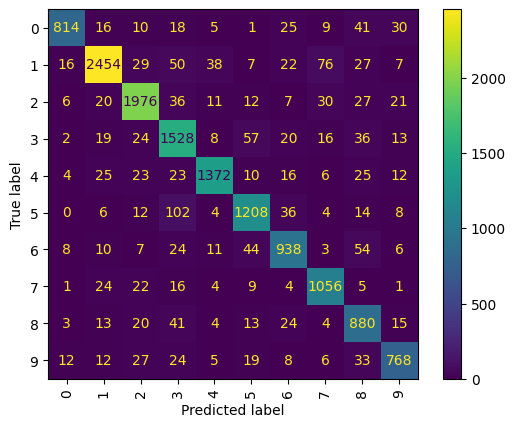

In [ ]:
plot_fn(mlp_train_losses, mlp_validation_losses)
confusion(CNN_model,validation_loader)

### Testing
Once the models have been trained and validated, we perform testing on the test dataset to assess the MLP, RNN, and CNN models was able to generalize the data.

In [ ]:
print("MLP Model:")
test(MLP_model, criterion)
print("\nRNN Model:")
test(RNN_model, criterion)
print("\nCNN Model:")
test(CNN_model, criterion)

MLP Model:
Test Loss: 0.8298
Test Accuracy: 77.1666

RNN Model:
Test Loss: 1.2276
Test Accuracy: 59.6766

CNN Model:
Test Loss: 0.4216
Test Accuracy: 87.9110


**Dataset**

torchvision.dataset.SVHN
https://docs.pytorch.org/vision/main/generated/torchvision.datasets.SVHN.html